# Week 6 — Reading a Spectrum: Bins, Phase, the FFT, and Honest Peaks

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def time_axis(fs, duration):
    T = 1/fs
    t = np.arange(0, duration, T)
    return t

def generate_sine(f, t, A=1, p=0):
    y = A * np.sin(2 * np.pi * f * t + p)
    return y

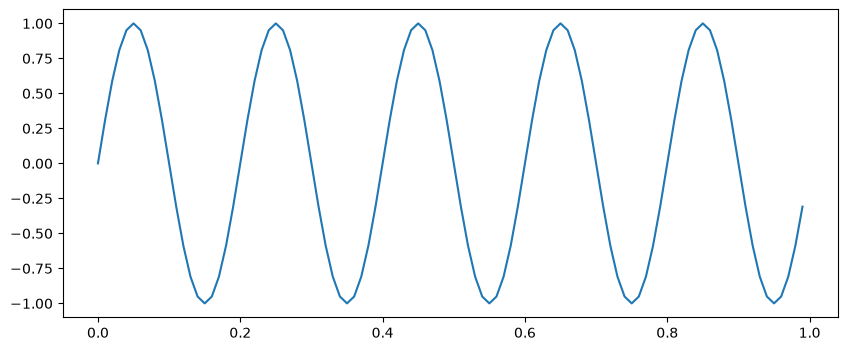

In [25]:
fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(5, t, A=1.0, p=0)

plt.figure(figsize=(10,4))
plt.plot(t, x)
plt.show()

(-5.493903235864685e-15+0j)
(2.052211859526699e-15+1.7763568394002505e-15j)
2.7142249606961615e-15


Text(0.5, 0, 'index of k')

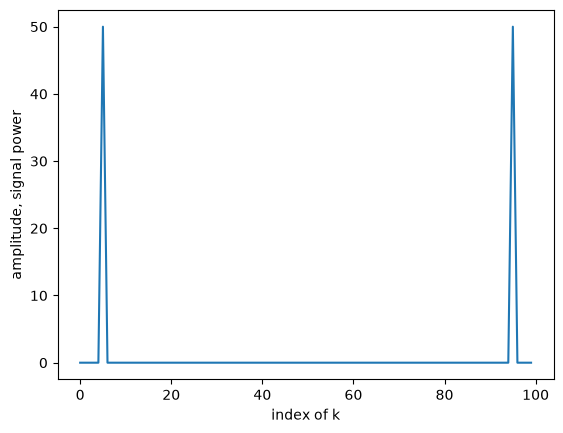

In [26]:
X = np.fft.fft(x)
print( X[0] )
# print(len(X))
print(X[1])

mag = np.abs(X)
print(mag[1])
# plt.plot(mag[1:10])
plt.plot(mag)
plt.ylabel("amplitude, signal power")
plt.xlabel("index of k")

In [27]:
# g = [1, 0, -1, 0]
# G = np.fft.fft(g)
# print(G[1])

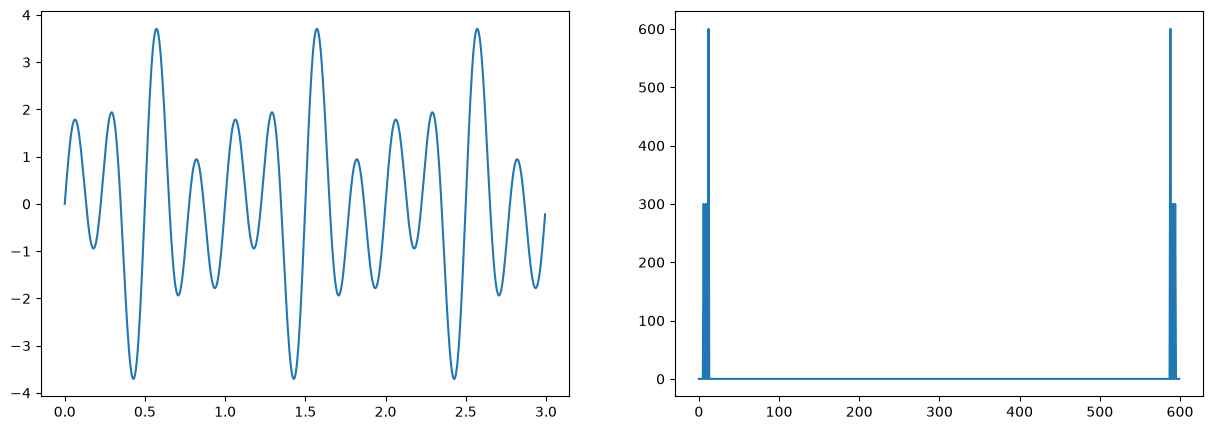

In [28]:
# Ex1. สร้างสัญญาณ fs=200 duration=3 ที่ผสม 3 ความถี่
# plot สัญญาณต้นฉบับ (1,2,1) และ magnitude ของความถี่ (1,2,2)
t = time_axis(fs = 200, duration = 3)
y1= generate_sine(3, t, 1, np.pi)
y2= generate_sine(2, t, 1, 0)
y3= generate_sine(4, t, 2, 0)

signal = y1 + y2 + y3

plt.figure(figsize = (15, 5))
plt.subplot(1, 2, 1)
plt.plot(t, signal)

X = np.fft.fft(signal)
mag = np.abs(X)
plt.subplot(1, 2, 2)
plt.plot(mag)

plt.savefig("image/670710258.png")

In [29]:
# # test
# t = time_axis(fs = 200, duration = 100)
# y1= generate_sine(3, t, 1, np.pi)
# y2= generate_sine(2, t, 1, 0)
# y3= generate_sine(4, t, 2, 0)
#
# signal = y1 + y2 + y3
#
# plt.figure(figsize = (15, 5))
# plt.subplot(1, 2, 1)
# plt.plot(t, signal)
#
# X = np.fft.fft(signal)
# mag = np.abs(X)
# plt.subplot(1, 2, 2)
# plt.plot(mag)
#
# plt.savefig("image/670710258.png")

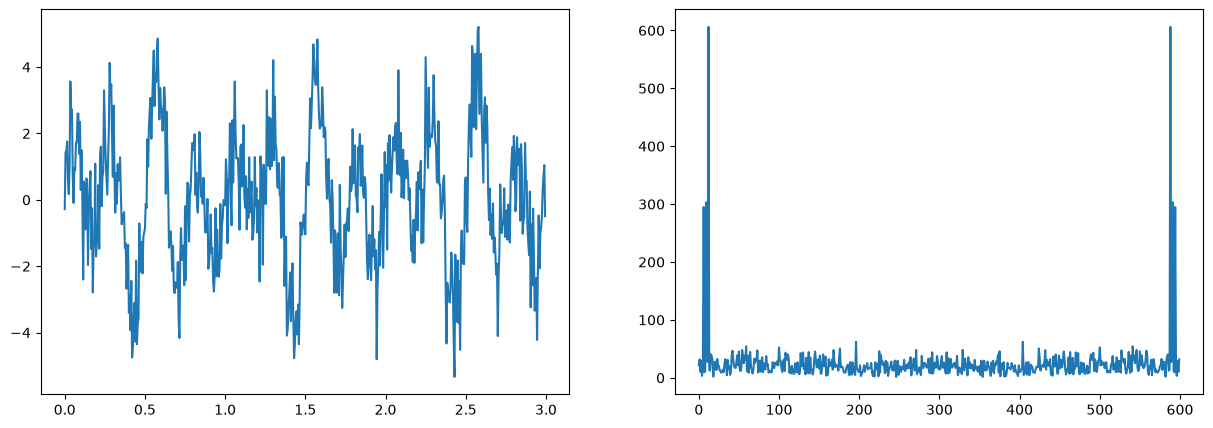

In [30]:
# Ex2. สร้างสัญญาณสุ่มด้วย np.random.normal(min, max, n) นำไปบวกกับสัญญาณข้อ 1
# plot สัญญาณต้นฉบับ (1,2,1) และ magnitude ของความถี่ (1,2,2)
noise = np.random.normal(0, 1, len(signal))
signal = signal + noise

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(t, signal)

X = np.fft.fft(signal)
mag = np.abs(X)
plt.subplot(1, 2, 2)
plt.plot(mag)

plt.savefig("image/670710258.png")

## Frequency bins, the mirror, and the one-sided spectrum

600


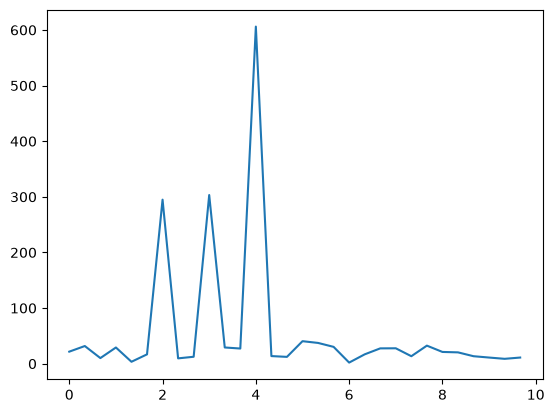

In [31]:
# Ex3 จาก Ex2 กำหนดแกน x ของ สัญญาณต้นฉบับเป็นหน่วยเวลา และกำหนดแกน x ของ magnitude เป็นความถี่ 
# หาความถี่ที่มี magnitude มากที่สุด (dominant frequency) และทำเครื่องหมายบนรูป

N = len(signal)
# print(N)

freq = np.arange(N) * 200/N
print(len(freq))
plt.plot(freq[:30], mag[:30])
# plt.ylabel()
plt.savefig("image/670710258.png")


In [32]:
def one_sided_spectrum(X, fs):
    N = len(X)
    half = N//2 + 1
    freqs = np.arange(half) * fs / N
    amp = 2 * np.abs(X[:half]) / N        
    amp[0] = amp[0] / 2                   
    amp[-1] = amp[-1] / 2             
    return freqs, amp

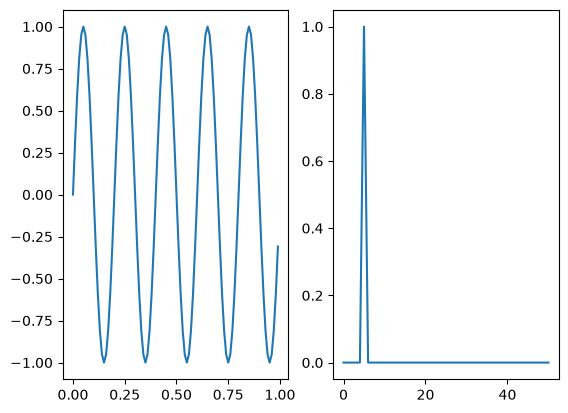

In [33]:
fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(5, t, A=1.0, p=0)
X = np.fft.fft(x)
freqs, amp = one_sided_spectrum(X, fs)

plt.subplot(1,2,1)
plt.plot(t, x)
plt.subplot(1,2,2)
plt.plot(freqs, amp)

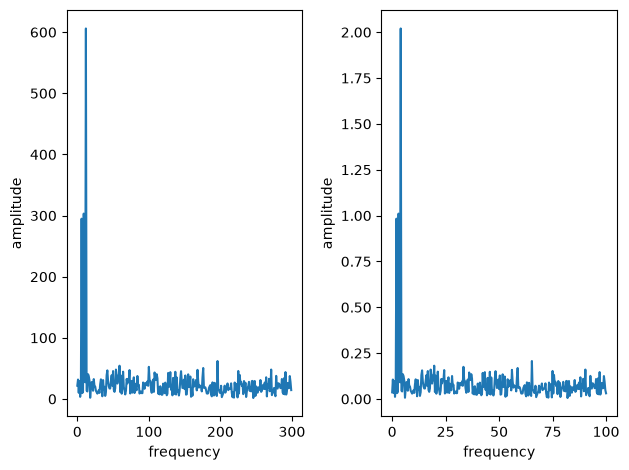

In [34]:
# Ex4. จาก Ex2 แสดง magnitude ครึ่งแรก และ ปรับสเกล 

X = np.fft.fft(signal)
freqs, amp = one_sided_spectrum(X, 200)
# print(amp)

plt.subplot(1, 2, 1)
plt.plot(mag[:N//2])
plt.ylabel("amplitude")
plt.xlabel("frequency")

plt.subplot(1, 2, 2)
plt.plot(freqs, amp)
plt.ylabel("amplitude")
plt.xlabel("frequency")

plt.tight_layout()
plt.savefig("image/670710258.png")


95.8544031474375
12 72.0


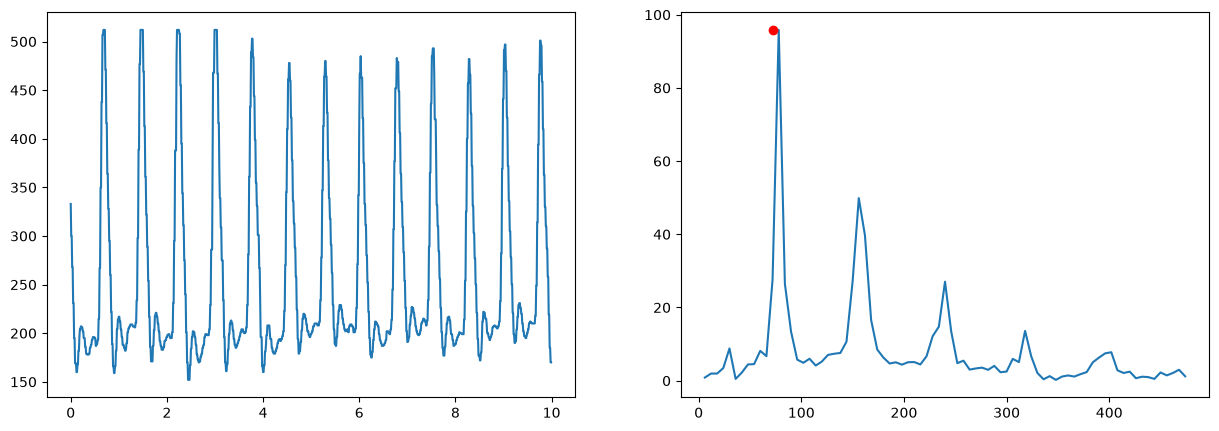

In [35]:
# Ex5. โหลดสัญญาณจากไฟล์ "pulse_100fs.txt" มี 4 columns: hr, min, sec, pulse
# นำ pulse 1000 ตัวแรกมา plot (1,2,1) โดยแสดงแกน x เป็นเวลา
# plot spectrum (1,2,2) โดยแสดงแกน x เป็นความถี่
with open("pulse_100fs.txt", "r") as file:
    lines = [line.split() for line in file]
    lines = np.array(lines, dtype=np.uint16)


    fs = 100
    pulse = lines[:, 3]
    t = time_axis(fs, len(pulse[:1000])/fs)
    # print(lines)
    # plt.plot(pulse[:1000]) # here x-axis 0-1000 ( index of pulse )
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(t, pulse[:1000]) # here x_axis 0-t (time axis)
    # another way to find t is use the smallest unit of time we have hr, mn, s -> change everything to s
    # t = lines[:1000, 0]*3600 + lines[:1000, 1]*60 + lines[:1000, 2]

    N = len(pulse[:1000])
    X = np.fft.fft(pulse[:1000])
    X = X[:N//2]
    mag = 2*np.abs(X)/N
    freq = np.arange(len(mag))*fs/N
    bpm = freq * 60 # beat per minutes

    plt.subplot(1, 2, 2)
    plt.plot(bpm[1:80], mag[1:80])
    plt.savefig("image/670710258.png")

    print(np.max(mag[1:80]))
    i = np.argmax(mag[1:80])
    print(i, bpm[i])
    plt.plot(bpm[i], np.max(mag[1:80]), "or")


## Magnitude and phase

1.0 -90.00000000000003


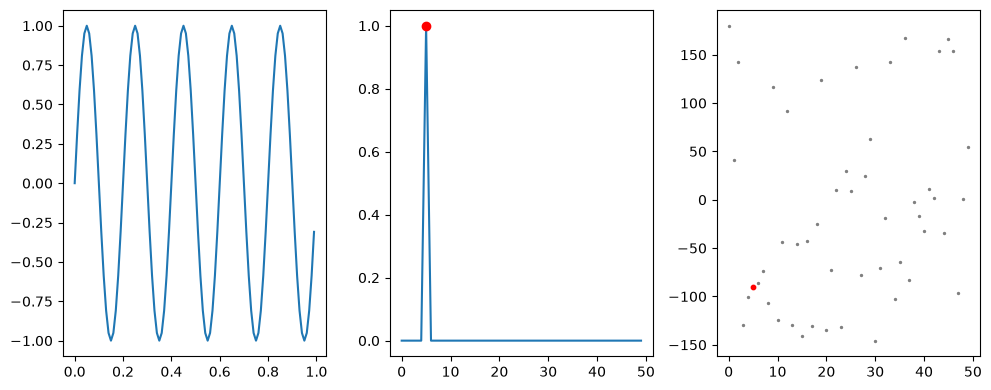

In [36]:
fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(5, t, A=1.0, p=0)
N = len(x)


X = np.fft.fft(x)[:N//2]
freq = np.arange(N//2)*fs/N
mag = 2*np.abs(X)/N
mag[0]/=2
mag[-1]/=2

phase = np.angle(X, deg = True)
# print(phase.shape)
i = np.argmax(mag)
print(mag[i], phase[i])

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.plot(t, x)

plt.subplot(1, 3, 2)
plt.plot(freq, mag)
plt.plot(freq[i], mag[i], "or")

plt.subplot(1, 3, 3)
# plt.plot(freq, phase, '.')
plt.scatter(freq, phase, s = 2 , color = "gray")

important = mag > 0.1
# plt.subplot(1, 3, 3)
# plt.plot(freq, phase, '.')
plt.scatter(freq[important], phase[important], s = 10 , color = "red")

plt.tight_layout()


2.02027233152174 -88.89173562419175


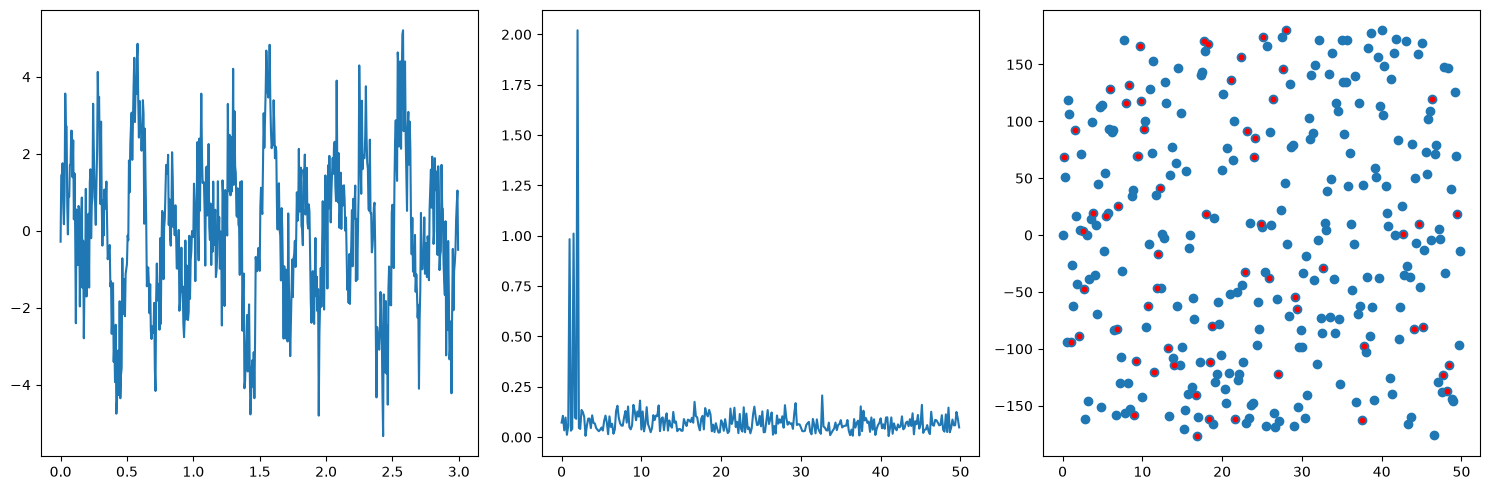

In [37]:
# Ex6. จาก Ex2 แสดง magnitude ครึ่งแรก และ ปรับสเกล 
# plot (1,3,1) สัญญาณต้นฉบับ, plot (1,3,2) แสดง spectrum, plot (1,3,3) แสดง phase โดยเน้นสีแดงที่ ความถี่ที่มี magnitude เกินกว่า 5% ของ max magnitude
t = time_axis(fs = 200, duration = 3)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(t, signal)

N = len(signal)
X = np.fft.fft(signal)
X = X[:N//2]
mag = 2*np.abs(X)/N
freq = np.arange(len(mag))*fs/N


plt.subplot(1, 3, 2)
plt.plot(freq, mag)

phase = np.angle(X, deg = True)
i = np.argmax(mag)
print(mag[i], phase[i])

important = mag > 0.05*mag[i]
plt.subplot(1, 3, 3)
plt.scatter(freq, phase)
plt.scatter(freq[important], phase[important], s = 10 , color = "red")


plt.tight_layout()
plt.savefig("image/670710258.png")


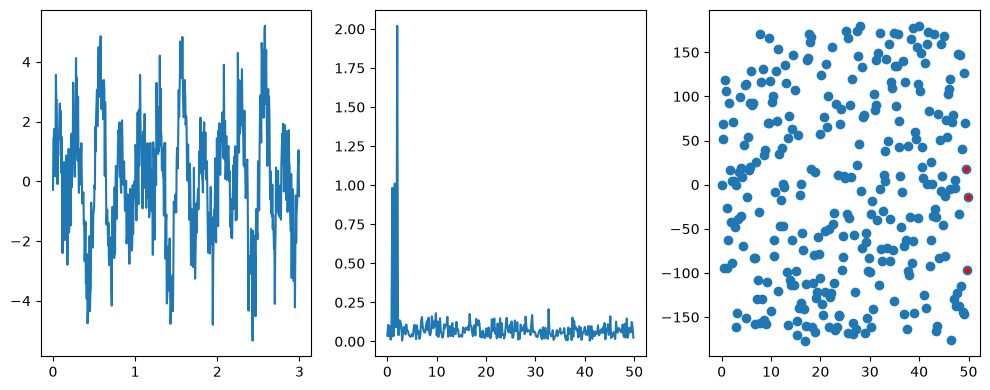

In [38]:
# Ex7 เหมือนข้อ 6 ทุกประการ ยกเว้น แสดง phase โดยเน้นสีแดง ที่ 3 ความถี่ ที่มี magnitude สูงสุด
t = time_axis(fs = 200, duration = 3)
N = len(signal)
X = np.fft.fft(signal)[:N//2]
freq = np.arange(N//2)*fs/N
mag = 2*np.abs(X)/N
mag[0]/=2
mag[-1]/=2

phase = np.angle(X, deg = True)
# print(phase.shape)
i = np.argmax(mag)
# print(mag[i], phase[i])

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.plot(t, signal)

plt.subplot(1, 3, 2)
plt.plot(freq, mag)

mag.sort()
# print(mag)
important = mag >= 0.93
plt.subplot(1, 3, 3)
plt.scatter(freq, phase)
plt.scatter(freq[important], phase[important], s = 10 , color = "red")


plt.tight_layout()
plt.savefig("image/670710258.png")



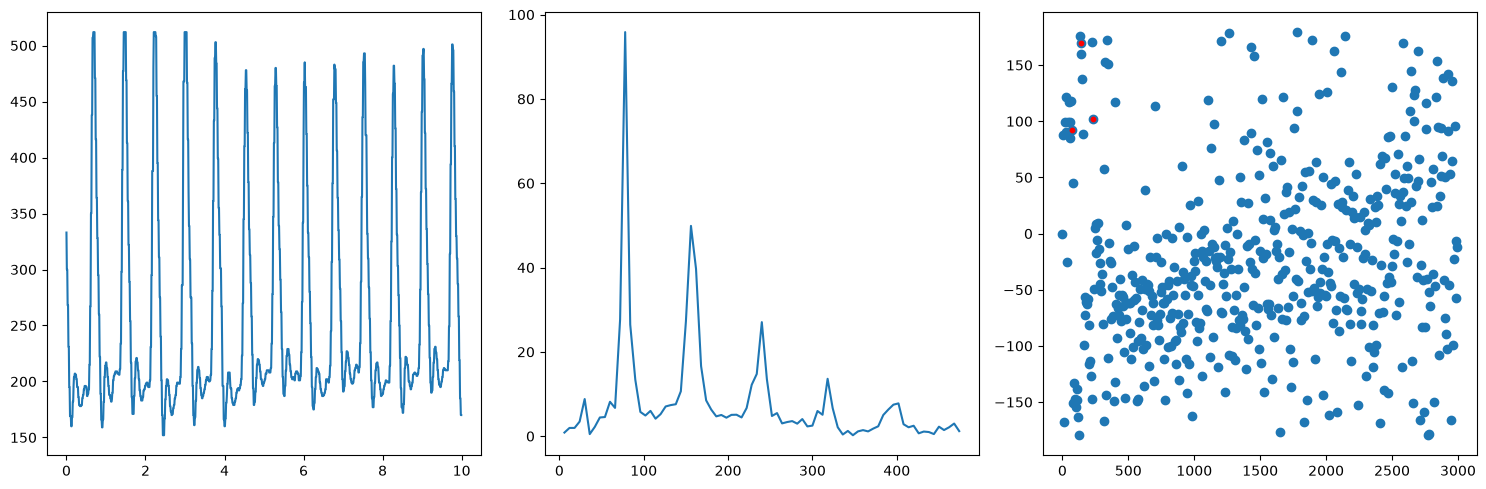

In [39]:
# Ex8 จากข้อ 5 แสดงผลลัพธ์เช่นเดียวกับข้อ 7
with open("pulse_100fs.txt", "r") as file:
    lines = [line.split() for line in file]
    lines = np.array(lines, dtype=np.uint16)


    fs = 100
    pulse = lines[:, 3]
    t = time_axis(fs, len(pulse[:1000])/fs)
    # print(lines)
    # plt.plot(pulse[:1000]) # here x-axis 0-1000 ( index of pulse )
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.plot(t, pulse[:1000]) # here x_axis 0-t (time axis)
    # another way to find t is use the smallest unit of time we have hr, mn, s -> change everything to s
    # t = lines[:1000, 0]*3600 + lines[:1000, 1]*60 + lines[:1000, 2]

    N = len(pulse[:1000])
    X = np.fft.fft(pulse[:1000])
    X = X[:N//2]
    mag = 2*np.abs(X)/N
    freq = np.arange(len(mag))*fs/N
    bpm = freq * 60 # beat per minutes

    plt.subplot(1, 3, 2)
    plt.plot(bpm[1:80], mag[1:80])

    # mag.sort()
    # print(mag)
    important = mag > 20
    # print(important)
    phase = np.angle(X, deg=True)
    plt.subplot(1, 3, 3)
    plt.scatter(bpm, phase)
    plt.scatter(bpm[12], phase[12], s = 10 , color = "red")
    plt.scatter(bpm[24], phase[24], s = 10 , color = "red")
    plt.scatter(bpm[39], phase[39], s = 10 , color = "red")

    plt.tight_layout()
    plt.savefig("image/670710258.png")


## The FFT, off-bin tones, leakage, and analysis tapers

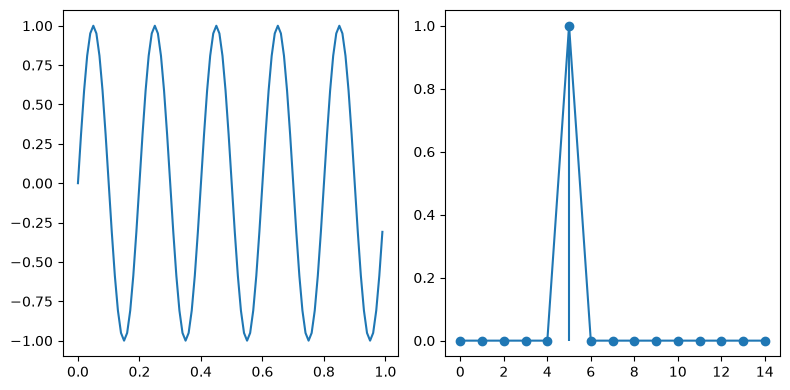

In [40]:
fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(5, t, A=1.0, p=0)
N = len(x)
X = np.fft.fft(x)[:N//2]
nfft = len(X)
freqs = np.arange(N//2) * fs / N

mag = 2*np.abs(X)/N
mag[0]/=2
mag[-1]/=2

plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plt.plot(t, x)
plt.subplot(1,2,2)
plt.plot(freqs[:15], mag[:15], 'o-')
plt.vlines(freqs[:10], 0, mag[:10])

plt.tight_layout()
plt.show()

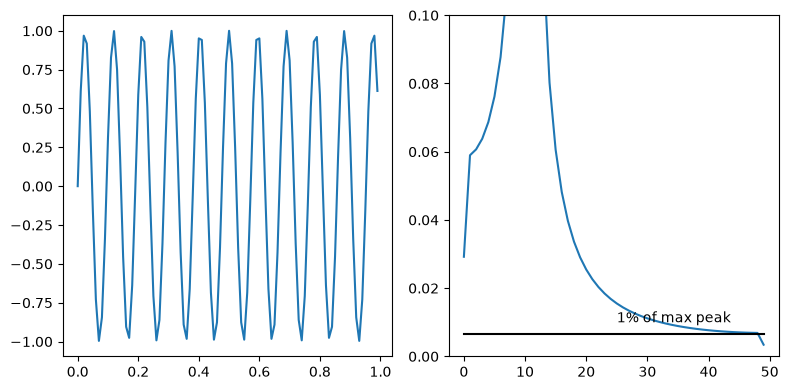

In [50]:
fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(10.5, t, A=1.0, p=0)
N = len(x)
X = np.fft.fft(x)[:N//2]
nfft = len(X)
freqs = np.arange(N//2) * fs / N

mag = 2*np.abs(X)/N
mag[0]/=2
mag[-1]/=2

plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plt.plot(t, x)
plt.subplot(1,2,2)
plt.plot(freqs[:50], mag[:50], '-')
plt.plot(np.ones(50)*0.01*np.max(mag), 'k')
plt.text(25, 0.01, "1% of max peak")
plt.ylim(0, 0.1)
# plt.vlines(freqs[:10], 0, mag[:10])

plt.tight_layout()
plt.show()

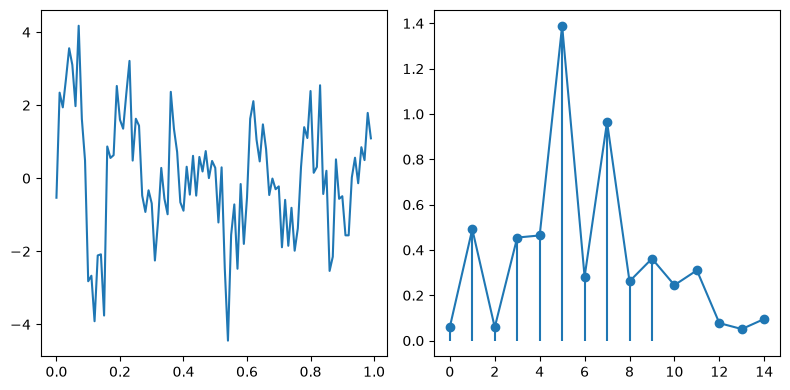

In [42]:
fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(5, t, A=1.0, p=0) + generate_sine(5.5, t, A=1.0, p=0) + generate_sine(6.5, t, A=1.0, p=0)
x += np.random.normal(0, 1, len(x)) 
N = len(x)
X = np.fft.fft(x)[:N//2]
nfft = len(X)
freqs = np.arange(N//2) * fs / N

mag = 2*np.abs(X)/N
mag[0]/=2
mag[-1]/=2

plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plt.plot(t, x)
plt.subplot(1,2,2)
plt.plot(freqs[:15], mag[:15], 'o-')
plt.vlines(freqs[:10], 0, mag[:10])

plt.tight_layout()
plt.show()

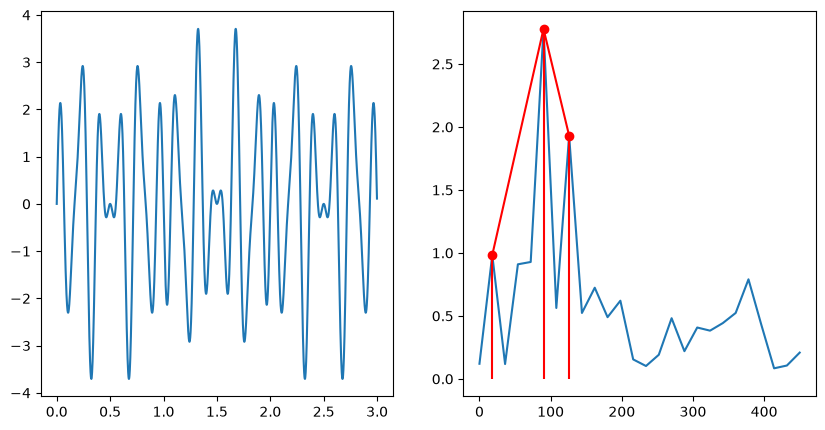

In [49]:
# Ex9 ที่ fs=200 duration=3 สร้างสัญญาณ 3 ความถี่ 3.5, 5.5, 8.5 
# plot (1,2,1) สัญญาณต้นฉบับ และ (1,2,2) spectrum 
# รายงานความถี่ที่มี amplitude สูงสุด 3 อันดับแรก

fs = 900
duration = 3
t = time_axis(fs, duration)
x = generate_sine(3.5, t, 1, np.pi) + generate_sine(5.5, t, 2, 0) + generate_sine(8.5, t, 1, 0)

plt.figure(figsize=(10, 5))
freqs, mag = one_sided_spectrum(X, fs)

# mag.sort()
# print(mag)

important = mag >= 0.98
plt.subplot(1, 2, 1); plt.plot(t, x)
plt.subplot(1, 2, 2); plt.plot(freqs, mag)
# plt.plot(freqs[:15], mag[:15], 'o-')

plt.plot(freqs[important], mag[important], color = "red", marker='o')
plt.vlines(freqs[important], 0, mag[important], color = "red")

plt.savefig("image/670710258.png")



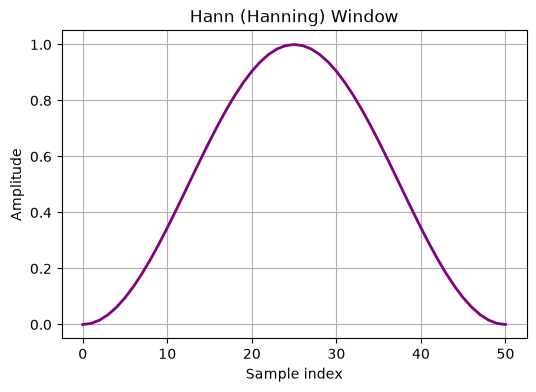

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import hann

# กำหนดจำนวนจุดข้อมูล (ความยาวหน้าต่าง)
M = 51

# สร้างหน้าต่าง Hanning (Hann)
window = hann(M)

# แสดงผลกราฟ
plt.figure(figsize=(6, 4))
plt.plot(window, color='purple', linewidth=2)
plt.title("Hann (Hanning) Window")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [ ]:
fs = 100
t = time_axis(fs, 1.0)
x = generate_sine(5, t, A=1.0, p=0)
window = hann(len(x))

x2 = x*window
plt.subplot(1,2,1)
plt.plot(t, x)
plt.plot(t, window)
plt.plot(t, x2, 'green')

X = np.fft.fft(x)
mag = 2*np.abs(X)/len(x)
freq = np.arange(len(mag)) * fs / len(X)
plt.subplot(1,2,2)
plt.plot(freq[:10], mag[:10])

X2 = np.fft.fft(x2)
mag2 = 2*np.abs(X2)/len(x2)
plt.subplot(1,2,2)
plt.plot(freq[:10], mag2[:10], 'green')
plt.show()

In [ ]:
# Ex10 จากข้อ 2 นำสัญญาณมาผ่าน hanning window
# plot (2,2,1) สัญญาณต้นฉบับ และ (2,2,2) spectrum 
# plot (2,2,3) สัญญาณที่ผ่าน hanning และ (2,2,4) spectrum
# รายงานความถี่ที่มี amplitude สูงสุด 3 อันดับแรก



In [ ]:
# Ex11 จากข้อ 5 นำสัญญาณมาผ่าน hanning window
# plot (2,2,1) สัญญาณต้นฉบับ และ (2,2,2) spectrum 
# plot (2,2,3) สัญญาณที่ผ่าน hanning และ (2,2,4) spectrum
# รายงานความถี่ที่มี amplitude สูงสุด 3 อันดับแรก

